In [1]:
# ! uv pip install langgraph-bigtool --quiet

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.openai_api_key = os.getenv("OPENAI_API_KEY")
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

## Langsmith params for observability
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGSMITH_PROJECT'] = 'LLM_OBS_YT'
os.environ['LANGSMITH_TRACING']="true"

In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults
import math
import types
import uuid
from langchain.embeddings import init_embeddings
from langchain.chat_models import init_chat_model
from langgraph.store.memory import InMemoryStore
from langchain_community.document_loaders import PyPDFLoader
# from langchain.embeddings import HuggingFaceBgeEmbeddings
from langchain_community.vectorstores import Chroma

In [3]:
### Embddings model initialization
embeddings = init_embeddings("openai:text-embedding-3-small")

### llm initialization
llm = init_chat_model("gpt-4o-mini")

In [4]:
loader = PyPDFLoader('sample_doc.pdf')
docs = loader.load()

### Creating Retriever using Vector DB
db = Chroma.from_documents(docs, embeddings)
retriever = db.as_retriever(search_kwargs={"k": 3})

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [5]:
### RAG Search Function
def rag_search(query:str):
    """Function to do RAG search for transformer and multihead attention related queries."""
    docs = retriever.invoke(query,)
    return "\nRetrieved documents:\n" + "".join(
        [
            f"\n\n===== Document {str(i)} =====\n" + doc.page_content
            for i, doc in enumerate(docs)
        ]
    )

### Web Search Function
tavily_tool = TavilySearchResults(max_results=5)
def web_search(query: str) -> str:
    """Search the web for information for the recent events like Cricket/Football of the world"""
    docs = tavily_tool.invoke({"query": query})
    web_results = "\n".join([d["content"] for d in docs])
    return web_results

/var/folders/57/y3hsdcy135b1wr5gzcw3b3kr0000gn/T/ipykernel_53158/1216941975.py:13: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


In [6]:
from langgraph_bigtool import create_agent
from langgraph_bigtool.utils import convert_positional_only_function_to_tool

# Collect functions from `math` built-in
all_tools = []
for function_name in [rag_search, web_search]:
    if tool := convert_positional_only_function_to_tool(function_name):
        all_tools.append(tool)

/var/folders/57/y3hsdcy135b1wr5gzcw3b3kr0000gn/T/ipykernel_53158/1381144433.py:7: LangChainBetaWarning: The function `convert_positional_only_function_to_tool` is in beta. It is actively being worked on, so the API may change.
  if tool := convert_positional_only_function_to_tool(function_name):


In [7]:
all_tools

[StructuredTool(name='rag_search', description='Function to do RAG search for transformer and multihead attention related queries.', args_schema=<class 'langchain_core.utils.pydantic.rag_search'>, func=<function rag_search at 0x10d21aca0>),
 StructuredTool(name='web_search', description='Search the web for information for the recent events like Cricket/Football of the world', args_schema=<class 'langchain_core.utils.pydantic.web_search'>, func=<function web_search at 0x10eaad580>)]

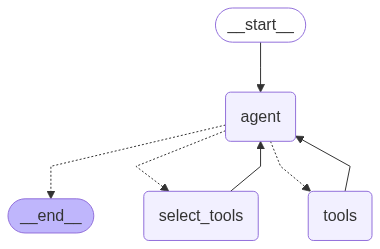

In [8]:
# Create registry of tools. This is a dict mapping
# identifiers to tool instances.
tool_registry = {
    str(uuid.uuid4()): tool
    for tool in all_tools
}

# Index tool names and descriptions in the LangGraph
# Store. Here we use a simple in-memory store.

store = InMemoryStore(
    index={
        "embed": embeddings,
        "dims": 1536,
        "fields": ["description"],
    }
)
for tool_id, tool in tool_registry.items():
    store.put(
        ("tools",),
        tool_id,
        {
            "description": f"{tool.name}: {tool.description}",
        },
    )

builder = create_agent(llm, tool_registry)
agent = builder.compile(store=store)
agent

In [9]:
result = agent.invoke(
    {
    "messages": [
        {
            "role": "user",
            "content": "who is the winner of Last T20 Cricket World Cup?"
        }
    ]}
)

In [10]:
result

{'messages': [HumanMessage(content='who is the winner of Last T20 Cricket World Cup?', additional_kwargs={}, response_metadata={}, id='653fb91c-94ec-4ebe-ba83-7337729e09d3'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_i1C3pqbbmqju3Me4b2asNRYj', 'function': {'arguments': '{"query":"Last T20 Cricket World Cup winner 2023"}', 'name': 'retrieve_tools'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 60, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-BxxDrLGW98GrCinnXxjZ6q657h9GO', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--cd1b2eda-8b6d-4bdf-950f-7781ecc0756c-0', tool_calls=[{'name'

In [11]:
result['messages'][-1].content

"The winner of the last ICC Men's T20 World Cup, held in 2022, is England. They claimed the title by defeating Pakistan in the final match at the Melbourne Cricket Ground on November 13, 2022. This victory marked England's second T20 World Cup title, having also won the tournament in 2010. \n\nThe next T20 World Cup is scheduled for 2024, and India won that tournament against South Africa."